# 02 -- Datenqualität der weiteren Indikatoren

Dieses Notebook analysiert die Datenverfügbarkeit aller Indikatoren aus dem Ordner
`Further Indicator DBs` für den in Notebook 01 festgelegten Analyserahmen:

| Dimension | Wert |
|-----------|------|
| **Länder** | 119 Studienländer (ISO3-Codes aus `config.json`) |
| **Zeitraum** | 2007–2022 (16 Jahre) |

Für jeden Indikator werden berechnet:
- **Länderabdeckung (%):** Anteil der 119 Länder mit mind. einem gültigen Datenpunkt im Zeitraum
- **Jahresabdeckung (%):** Ø Anteil der 16 Jahre mit Datenpunkt je Land (gemittelt über alle 119 Länder)

**Methodik:** identisch zu Notebook 01, Task 4.

## 0 -- Setup

In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import zipfile
import re
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Pfade (relativ zum /code-Verzeichnis)
FURTHER_DB = Path('..') / 'Further Indicator DBs'
OUTPUT_DIR = Path('Created Files for Analysis')

## 1 -- Konfiguration laden

Alle Analyseentscheidungen (Länderliste, Zeitraum) stammen aus `config.json`,
das in Notebook 01 erzeugt wurde.

In [126]:
with open(OUTPUT_DIR / 'config.json', 'r', encoding='utf-8') as f:
    config = json.load(f)

INCLUDED_COUNTRIES = config['included_countries']   # 119 Länder (ISO3)
YEAR_START         = config['year_start']            # 2007
YEAR_END           = config['year_end']              # 2022
N_YEARS            = config['n_years']               # 16
N_COUNTRIES        = config['n_countries']           # 119

print(f'Studienländer:   {N_COUNTRIES}')
print(f'Studienzeitraum: {YEAR_START}–{YEAR_END} ({N_YEARS} Jahre)')

Studienländer:   119
Studienzeitraum: 2007–2022 (16 Jahre)


## 2 -- Hilfsfunktionen

### Lesefunktionen (je DB-Format)
- `read_wdi()`: World Bank WDI-Format (XLS, Header Zeile 3)
- `read_eer()`: BIS Effective Exchange Rates (ZIP/CSV, Monatsfrequenz)
- `read_global_debt()`: IMF Global Debt Database (XLSX, Sheet `rawdata`)

### Coverage-Berechnung
- `compute_coverage()`: Länder- und Jahresabdeckung (identisch zu Notebook 01)
- `display_indicator_coverage()`: Formatierte Ausgabe mit farbiger Jahrestabelle

In [127]:
# ──────────────────────────────────────────────────────────────
# Lesefunktionen
# ──────────────────────────────────────────────────────────────

def read_wdi(filepath):
    """
    Liest eine WDI-Format XLS-Datei (World Bank World Development Indicators).
    Format: Header in Zeile 3 (0-indiziert), Jahresdaten als Spalten (1960.0, ...).
    Gibt Long-Format DataFrame (ISO3, Year, Value) zurück.
    """
    df = pd.read_excel(filepath, sheet_name='Data', header=3)
    df = df.rename(columns={'Country Code': 'ISO3'})
    df['ISO3'] = df['ISO3'].astype(str).str.strip()

    # Jahresspalten identifizieren (numerisch, im Studienzeitraum)
    year_map = {}
    for col in df.columns:
        try:
            yr = int(float(str(col)))
            if YEAR_START <= yr <= YEAR_END:
                year_map[col] = yr
        except (ValueError, TypeError):
            pass

    if not year_map:
        return pd.DataFrame(columns=['ISO3', 'Year', 'Value'])

    df_long = df[['ISO3'] + list(year_map.keys())].melt(
        id_vars='ISO3', var_name='Year_raw', value_name='Value'
    )
    df_long['Year'] = df_long['Year_raw'].map(year_map).astype(int)
    df_long = df_long[['ISO3', 'Year', 'Value']].dropna(subset=['ISO3'])
    return df_long


def read_eer(filepath, bis_to_iso3):
    """
    Liest BIS Effective Exchange Rates aus ZIP-Datei.
    Verwendet: Realer EER (R), Breiter Korb (B), Monatsfrequenz (M).
    Aggregiert Monatswerte zu Jahresdurchschnitten.
    Gibt Long-Format DataFrame (ISO3, Year, Value) zurück.
    """
    with zipfile.ZipFile(filepath) as z:
        with z.open('WS_EER_csv_col.csv') as f:
            df = pd.read_csv(f)

    # Nur Real EER, Broad basket, Monatsfrequenz
    df = df[
        (df['FREQ']       == 'M') &
        (df['EER_TYPE']   == 'R') &
        (df['EER_BASKET'] == 'B')
    ].copy()

    # 2-stellige BIS-Codes auf ISO3 mappen
    df['ISO3'] = df['REF_AREA'].map(bis_to_iso3)
    df = df[df['ISO3'].notna()].copy()

    # Monatsspalten identifizieren (Format: YYYY-MM) und auf Studienzeitraum einschränken
    month_cols = [
        c for c in df.columns
        if re.match(r'^\d{4}-\d{2}$', str(c)) and YEAR_START <= int(str(c)[:4]) <= YEAR_END
    ]
    if not month_cols:
        return pd.DataFrame(columns=['ISO3', 'Year', 'Value'])

    df_long = df[['ISO3'] + month_cols].melt(
        id_vars='ISO3', var_name='Month', value_name='Value'
    )
    df_long['Year'] = df_long['Month'].str[:4].astype(int)
    df_long = df_long.dropna(subset=['Value'])

    # Jahresdurchschnitt (für Coverage: Existenz mind. eines Monatswerts je Jahr genügt)
    df_annual = (
        df_long.groupby(['ISO3', 'Year'])['Value']
        .mean()
        .reset_index()
    )
    return df_annual


def read_global_debt(filepath, gdd_name_to_iso3):
    """
    Liest IMF Global Debt Database.
    Verwendet Spalte cg_data (Central Government Debt, % of GDP).
    Gibt Long-Format DataFrame (ISO3, Year, Value) zurück.
    """
    df = pd.read_excel(filepath, sheet_name='rawdata', header=2)
    df['ISO3'] = df['country'].map(gdd_name_to_iso3)
    df = df[df['ISO3'].notna()].copy()
    df_long = df[['ISO3', 'year', 'cg_data']].rename(
        columns={'year': 'Year', 'cg_data': 'Value'}
    )
    return df_long


# ──────────────────────────────────────────────────────────────
# Coverage-Berechnung (identisch zu Notebook 01, Task 4)
# ──────────────────────────────────────────────────────────────

def compute_coverage(df_long):
    """
    Berechnet Länder- und Jahresabdeckung für einen Indikator.
    Basiert auf den globalen Konstanten INCLUDED_COUNTRIES, YEAR_START, YEAR_END.

    Returns dict:
        n_countries_with_data  : int   – Anzahl Länder mit mind. 1 Datenpunkt
        country_pct            : float – Länderabdeckung in %
        year_pct               : float – Ø Jahresabdeckung in % (über alle 119 Länder)
        yearly                 : DataFrame – Abdeckung je Jahr (Year, n_countries, coverage_pct)
    """
    df = df_long[
        df_long['ISO3'].isin(INCLUDED_COUNTRIES) &
        df_long['Year'].between(YEAR_START, YEAR_END) &
        df_long['Value'].notna()
    ].copy()

    # Länderabdeckung
    countries_with_data = df['ISO3'].nunique()
    country_pct = round(countries_with_data / N_COUNTRIES * 100, 1)

    # Jahresabdeckung: Ø Anteil Jahre mit Datenpunkt je Land
    if len(df) > 0:
        years_per_country = df.groupby('ISO3')['Year'].nunique()
        # Länder ganz ohne Daten erhalten 0
        missing = pd.Series(
            0, index=[c for c in INCLUDED_COUNTRIES if c not in years_per_country.index]
        )
        years_per_country = pd.concat([years_per_country, missing])
        year_pct = round(years_per_country.mean() / N_YEARS * 100, 1)
    else:
        year_pct = 0.0

    # Abdeckung je Studienjahr
    yearly = (
        df.groupby('Year')['ISO3']
        .nunique()
        .reindex(range(YEAR_START, YEAR_END + 1), fill_value=0)
        .reset_index()
    )
    yearly.columns = ['Year', 'n_countries']
    yearly['coverage_pct'] = (yearly['n_countries'] / N_COUNTRIES * 100).round(1)

    return {
        'n_countries_with_data': countries_with_data,
        'country_pct':           country_pct,
        'year_pct':              year_pct,
        'yearly':                yearly,
    }


# ──────────────────────────────────────────────────────────────
# Formatierte Ausgabe (wie Notebook 01)
# ──────────────────────────────────────────────────────────────

def display_indicator_coverage(cov, indicator_name, code=''):
    """
    Zeigt Coverage-Ergebnisse formatiert an.
    Jahrliche Abdeckung als farbige Tabelle (RdYlGn-Gradient, wie Notebook 01).
    """
    label = indicator_name + (f'  [{code}]' if code else '')
    print(f'=== {label} ===')
    print(f'  Länderabdeckung: {cov["n_countries_with_data"]}/{N_COUNTRIES} Länder '
          f'({cov["country_pct"]:.1f}%)')
    print(f'  Jahresabdeckung: {cov["year_pct"]:.1f}% (Ø Anteil Studienjahre je Land)')
    print()

    # Jahrliche Tabelle als Pivot (eine Zeile = Indikator, Spalten = Jahre)
    yearly = cov['yearly'].copy()
    pivot = yearly.set_index('Year')['coverage_pct'].to_frame().T
    pivot.index = [indicator_name]

    display(
        pivot
        .style
        .format('{:.1f}%')
        .background_gradient(cmap='RdYlGn', vmin=0, vmax=100, axis=1)
        .set_caption(
            f'Datenabdeckung je Jahr (% der {N_COUNTRIES} Studienländer) — '
            f'Gesamt: {cov["country_pct"]:.1f}% Länder | {cov["year_pct"]:.1f}% Jahre'
        )
    )

def read_swiid(filepath, swiid_name_to_iso3):
    """
    Liest SWIID Summary CSV aus dem verschachtelten ZIP-Archiv
    (dataverse_files.zip → swiid9_92.zip → swiid9_92_summary.csv).
    Gibt den vollständigen DataFrame zurück; Ländernamen werden über
    swiid_name_to_iso3 auf ISO3-Codes gemappt.
    Spalten von Interesse: gini_disp, gini_mkt, abs_red, rel_red (je mit _se).
    """
    import io
    with zipfile.ZipFile(filepath) as outer:
        with outer.open('swiid9_92.zip') as inner_bytes:
            with zipfile.ZipFile(io.BytesIO(inner_bytes.read())) as inner:
                with inner.open('swiid9_92/swiid9_92_summary.csv') as f:
                    df = pd.read_csv(f)
    df['ISO3'] = df['country'].map(swiid_name_to_iso3)
    return df

## 3 -- Mapping-Dictionaries

### 3.1 BIS → ISO3 (Effective Exchange Rates)
Die BIS EER-Daten verwenden 2-stellige Ländercodes. Das Mapping erfolgt manuell.

### 3.2 IMF-Ländernamen → ISO3 (Global Debt Database)
Die GDD verwendet IMF-spezifische Ländernamen. Grundlage ist ein exakter Match
mit den WDI-Namen (aus `country_list.xlsx`); abweichende IMF-Namen werden
manuell überschrieben.

In [128]:
# ──────────────────────────────────────────────────────────────
# 3.1  BIS 2-Zeichen-Code → ISO3
# ──────────────────────────────────────────────────────────────
BIS_TO_ISO3 = {
    'AE': 'ARE', 'AR': 'ARG', 'AT': 'AUT', 'AU': 'AUS',
    'BA': 'BIH', 'BE': 'BEL', 'BG': 'BGR', 'BR': 'BRA',
    'CA': 'CAN', 'CH': 'CHE', 'CL': 'CHL', 'CN': 'CHN',
    'CO': 'COL', 'CY': 'CYP', 'CZ': 'CZE', 'DE': 'DEU',
    'DK': 'DNK', 'DZ': 'DZA', 'EE': 'EST', 'ES': 'ESP',
    'FI': 'FIN', 'FR': 'FRA', 'GB': 'GBR', 'GR': 'GRC',
    'HK': 'HKG', 'HR': 'HRV', 'HU': 'HUN', 'ID': 'IDN',
    'IE': 'IRL', 'IL': 'ISR', 'IN': 'IND', 'IS': 'ISL',
    'IT': 'ITA', 'JP': 'JPN', 'KR': 'KOR', 'LT': 'LTU',
    'LU': 'LUX', 'LV': 'LVA', 'MA': 'MAR', 'MK': 'MKD',
    'MT': 'MLT', 'MX': 'MEX', 'MY': 'MYS', 'NL': 'NLD',
    'NO': 'NOR', 'NZ': 'NZL', 'PE': 'PER', 'PH': 'PHL',
    'PL': 'POL', 'PT': 'PRT', 'RO': 'ROU', 'RS': 'SRB',
    'RU': 'RUS', 'SA': 'SAU', 'SE': 'SWE', 'SG': 'SGP',
    'SI': 'SVN', 'SK': 'SVK', 'TH': 'THA', 'TR': 'TUR',
    'TW': 'TWN', 'US': 'USA', 'ZA': 'ZAF',
    'XM': None,  # Euroraum-Aggregat – wird herausgefiltert
}

# Nur Codes, die tatsächlich in den Studienländern sind
eer_study_codes = {k: v for k, v in BIS_TO_ISO3.items()
                   if v is not None and v in INCLUDED_COUNTRIES}
print(f'BIS-Codes mit Studienbezug: {len(eer_study_codes)} '
      f'({len(eer_study_codes)}/{N_COUNTRIES} Studienländer abgedeckt)')

# ──────────────────────────────────────────────────────────────
# 3.2  IMF-Ländernamen → ISO3 (Global Debt Database)
# ──────────────────────────────────────────────────────────────

# Basis: WDI-Namen aus country_list.xlsx (105 direkte Matches)
cl_study = pd.read_excel(OUTPUT_DIR / 'country_list.xlsx')
GDD_NAME_TO_ISO3 = dict(zip(cl_study['Country_Name'], cl_study['ISO3']))

# Manuelle Korrekturen für IMF-spezifische Schreibweisen
GDD_NAME_TO_ISO3.update({
    'U.A.E.':                          'ARE',
    'Bosnia & Herzegovina':            'BIH',
    'China, Mainland':                 'CHN',
    'Congo, Republic of':              'COG',
    'Czech Republic':                  'CZE',
    'Egypt':                           'EGY',
    'Hong Kong SAR':                   'HKG',
    'Iran, I. Rep. Of':                'IRN',
    'Korea, Republic of':              'KOR',
    'Macedonia, FYR':                  'MKD',
    # Türkiye: wird dynamisch unten ergaenzt (Sonderzeichen-Robustheit)
    'Venezuela, Republica Bolivariana de': 'VEN',
    'Vietnam':                         'VNM',
    'Yemen':                           'YEM',
})

# Tueerkiye: dynamisch suchen (Sonderzeichen-Encoding je nach xlsx-Lesart)
for _gdd_name in pd.read_excel(FURTHER_DB / "GlobalDebtDatabase.xlsx",
                               sheet_name="rawdata", header=2)["country"].dropna().unique():
    if "rkiye" in str(_gdd_name):
        GDD_NAME_TO_ISO3[_gdd_name] = "TUR"

# Validierung: Welche Studienländer sind in der GDD enthalten?
gdd_raw = pd.read_excel(FURTHER_DB / 'GlobalDebtDatabase.xlsx',
                        sheet_name='rawdata', header=2)
gdd_countries_mapped = gdd_raw['country'].map(GDD_NAME_TO_ISO3).dropna().unique()
gdd_study_countries  = [c for c in gdd_countries_mapped if c in INCLUDED_COUNTRIES]

print(f'\nGDD Studienländer gefunden: {len(gdd_study_countries)}/{N_COUNTRIES}')
not_in_gdd = [c for c in INCLUDED_COUNTRIES if c not in gdd_study_countries]
if not_in_gdd:
    print(f'Nicht in GDD: {not_in_gdd}')

# ──────────────────────────────────────────────────────────────────────────────
# 3.3  SWIID Ländernamen → ISO3
# ──────────────────────────────────────────────────────────────────────────────
# Basis: WDI-Namen aus country_list.xlsx
_cl = pd.read_excel(OUTPUT_DIR / 'country_list.xlsx')
SWIID_NAME_TO_ISO3 = dict(zip(_cl['Country_Name'], _cl['ISO3']))

# Manuelle Korrekturen für SWIID-spezifische Schreibweisen
SWIID_NAME_TO_ISO3.update({
    'Czech Republic':              'CZE',   # SWIID: "Czech Republic", WDI: "Czechia"
    'South Korea':                 'KOR',
    'Korea':                       'KOR',
    'Russia':                      'RUS',
    'Iran':                        'IRN',
    'Vietnam':                     'VNM',
    'Yemen':                       'YEM',
    'Congo, Republic of the':      'COG',
    'Republic of the Congo':       'COG',
    'Congo, Rep.':                 'COG',
    'Hong Kong':                   'HKG',
    'Venezuela':                   'VEN',
    'Slovakia':                    'SVK',
    'North Macedonia':             'MKD',
    'Macedonia':                   'MKD',
    'Turkey':                      'TUR',
    'Egypt':                       'EGY',
    'Bosnia and Herzegovina':      'BIH',
    'Kyrgyzstan':                  'KGZ',
    'Moldova':                     'MDA',
    'Cambodia':                    'KHM',
    'UAE':                         'ARE',
    'United Arab Emirates':        'ARE',
})

# Validierung
_swiid_test = read_swiid(FURTHER_DB / 'dataverse_files.zip', SWIID_NAME_TO_ISO3)
_swiid_covered = set(
    _swiid_test[
        _swiid_test['ISO3'].isin(INCLUDED_COUNTRIES) &
        _swiid_test['year'].between(YEAR_START, YEAR_END)
    ]['ISO3'].unique()
)
_swiid_missing = sorted(set(INCLUDED_COUNTRIES) - _swiid_covered)
print(f'SWIID Studienländer gefunden: {len(_swiid_covered)}/{N_COUNTRIES}')
if _swiid_missing:
    _iso3_name = dict(zip(_cl['ISO3'], _cl['Country_Name']))
    print(f'Nicht in SWIID: {[(c, _iso3_name.get(c)) for c in _swiid_missing]}')

BIS-Codes mit Studienbezug: 58 (58/119 Studienländer abgedeckt)

GDD Studienländer gefunden: 119/119
SWIID Studienländer gefunden: 117/119
Nicht in SWIID: [('COG', 'Congo, Rep.'), ('PSE', 'West Bank and Gaza')]


## 4 -- Coverage-Analyse je Indikator

Für jeden Indikator wird die Datenverfügbarkeit im Analyserahmen
(119 Länder, 2007–2022) berechnet und visualisiert.
Die Ergebnisse werden in `results` gesammelt und in Abschnitt 5 zusammengefasst.

In [129]:
# Ergebnisliste für Gesamtübersicht (Abschnitt 5)
results = []

### 4.1 Inflation (CPI)

**WDI-Code:** `FP.CPI.TOTL.ZG`  
**Quelle:** World Bank World Development Indicators

In [130]:
FILE_4_1 = FURTHER_DB / 'Inflation.xls'
df_4_1  = read_wdi(FILE_4_1)
cov_4_1 = compute_coverage(df_4_1)
display_indicator_coverage(cov_4_1, 'Inflation (CPI)', 'FP.CPI.TOTL.ZG')
results.append({
    'Abschnitt':           '4.1',
    'Indikator':           'Inflation (CPI)',
    'Code':                'FP.CPI.TOTL.ZG',
    'Laenderabdeckung_pct': cov_4_1['country_pct'],
    'Jahresabdeckung_pct':  cov_4_1['year_pct'],
})

=== Inflation (CPI)  [FP.CPI.TOTL.ZG] ===
  Länderabdeckung: 119/119 Länder (100.0%)
  Jahresabdeckung: 97.7% (Ø Anteil Studienjahre je Land)



Year,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
Inflation (CPI),95.0%,95.8%,97.5%,98.3%,99.2%,99.2%,99.2%,99.2%,98.3%,98.3%,96.6%,97.5%,97.5%,97.5%,97.5%,97.5%


### 4.2 BIP-Deflator

**WDI-Code:** `NY.GDP.DEFL.KD.ZG`  
**Quelle:** World Bank World Development Indicators

In [131]:
FILE_4_2 = FURTHER_DB / 'GPD Deflator.xls'
df_4_2  = read_wdi(FILE_4_2)
cov_4_2 = compute_coverage(df_4_2)
display_indicator_coverage(cov_4_2, 'BIP-Deflator', 'NY.GDP.DEFL.KD.ZG')
results.append({
    'Abschnitt':           '4.2',
    'Indikator':           'BIP-Deflator',
    'Code':                'NY.GDP.DEFL.KD.ZG',
    'Laenderabdeckung_pct': cov_4_2['country_pct'],
    'Jahresabdeckung_pct':  cov_4_2['year_pct'],
})

=== BIP-Deflator  [NY.GDP.DEFL.KD.ZG] ===
  Länderabdeckung: 119/119 Länder (100.0%)
  Jahresabdeckung: 99.8% (Ø Anteil Studienjahre je Land)



Year,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
BIP-Deflator,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,99.2%,99.2%,99.2%,99.2%


### 4.3 Terms of Trade

**WDI-Code:** `TT.PRI.MRCH.XD.WD`  
**Quelle:** World Bank World Development Indicators

In [132]:
FILE_4_3 = FURTHER_DB / 'Terms of Trade.xls'
df_4_3  = read_wdi(FILE_4_3)
cov_4_3 = compute_coverage(df_4_3)
display_indicator_coverage(cov_4_3, 'Terms of Trade', 'TT.PRI.MRCH.XD.WD')
results.append({
    'Abschnitt':           '4.3',
    'Indikator':           'Terms of Trade',
    'Code':                'TT.PRI.MRCH.XD.WD',
    'Laenderabdeckung_pct': cov_4_3['country_pct'],
    'Jahresabdeckung_pct':  cov_4_3['year_pct'],
})

=== Terms of Trade  [TT.PRI.MRCH.XD.WD] ===
  Länderabdeckung: 118/119 Länder (99.2%)
  Jahresabdeckung: 98.9% (Ø Anteil Studienjahre je Land)



Year,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
Terms of Trade,98.3%,99.2%,99.2%,99.2%,99.2%,99.2%,99.2%,99.2%,99.2%,99.2%,99.2%,99.2%,98.3%,98.3%,98.3%,98.3%


### 4.4 Effektiver Wechselkursindex (REER)

**Quelle:** BIS (Bank for International Settlements)
**Sonderfall:** ZIP-Datei, Monats-/Tagesfrequenz, 2-stellige Ländercodes.
Verwendet wird der **reale** effektive Wechselkursindex (REER), breiter Korb (64 Länder),
Monatsfrequenz. Monatswerte werden zu Jahresdurchschnitten aggregiert.
Die BIS-Abdeckung ist auf ~63 Länder begrenzt; von den 119 Studienländern
sind voraussichtlich ~53 enthalten.

In [133]:
FILE_4_4 = FURTHER_DB / 'Effective Exchange Rates.zip'
df_4_4   = read_eer(FILE_4_4, BIS_TO_ISO3)
cov_4_4  = compute_coverage(df_4_4)
display_indicator_coverage(cov_4_4, 'Effektiver Wechselkursindex (REER)', 'BIS-REER-B')
results.append({
    'Abschnitt':            '4.4',
    'Indikator':            'Effektiver Wechselkursindex (REER)',
    'Code':                 'BIS-REER-B',
    'Laenderabdeckung_pct': cov_4_4['country_pct'],
    'Jahresabdeckung_pct':  cov_4_4['year_pct'],
})

=== Effektiver Wechselkursindex (REER)  [BIS-REER-B] ===
  Länderabdeckung: 58/119 Länder (48.7%)
  Jahresabdeckung: 48.7% (Ø Anteil Studienjahre je Land)



Year,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
Effektiver Wechselkursindex (REER),48.7%,48.7%,48.7%,48.7%,48.7%,48.7%,48.7%,48.7%,48.7%,48.7%,48.7%,48.7%,48.7%,48.7%,48.7%,48.7%


### 4.5 Leistungsbilanzsaldo

**WDI-Code:** `BN.CAB.XOKA.GD.ZS`  
**Quelle:** World Bank World Development Indicators

In [134]:
FILE_4_5 = FURTHER_DB / 'Leistungsbilanzsaldo.xls'
df_4_5  = read_wdi(FILE_4_5)
cov_4_5 = compute_coverage(df_4_5)
display_indicator_coverage(cov_4_5, 'Leistungsbilanzsaldo', 'BN.CAB.XOKA.GD.ZS')
results.append({
    'Abschnitt':           '4.5',
    'Indikator':           'Leistungsbilanzsaldo',
    'Code':                'BN.CAB.XOKA.GD.ZS',
    'Laenderabdeckung_pct': cov_4_5['country_pct'],
    'Jahresabdeckung_pct':  cov_4_5['year_pct'],
})

=== Leistungsbilanzsaldo  [BN.CAB.XOKA.GD.ZS] ===
  Länderabdeckung: 116/119 Länder (97.5%)
  Jahresabdeckung: 95.8% (Ø Anteil Studienjahre je Land)



Year,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
Leistungsbilanzsaldo,95.0%,95.8%,96.6%,96.6%,96.6%,97.5%,97.5%,97.5%,97.5%,96.6%,94.1%,94.1%,95.0%,95.0%,94.1%,93.3%


### 4.6 Breite Geldmenge (M2)

**WDI-Code:** `FM.LBL.BMNY.GD.ZS`  
**Quelle:** World Bank World Development Indicators

In [135]:
FILE_4_6 = FURTHER_DB / 'Broad Money.xls'
df_4_6  = read_wdi(FILE_4_6)
cov_4_6 = compute_coverage(df_4_6)
display_indicator_coverage(cov_4_6, 'Breite Geldmenge (M2)', 'FM.LBL.BMNY.GD.ZS')
results.append({
    'Abschnitt':           '4.6',
    'Indikator':           'Breite Geldmenge (M2)',
    'Code':                'FM.LBL.BMNY.GD.ZS',
    'Laenderabdeckung_pct': cov_4_6['country_pct'],
    'Jahresabdeckung_pct':  cov_4_6['year_pct'],
})

=== Breite Geldmenge (M2)  [FM.LBL.BMNY.GD.ZS] ===
  Länderabdeckung: 99/119 Länder (83.2%)
  Jahresabdeckung: 78.3% (Ø Anteil Studienjahre je Land)



Year,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
Breite Geldmenge (M2),81.5%,81.5%,80.7%,80.7%,79.8%,79.8%,81.5%,79.8%,79.8%,79.8%,79.0%,77.3%,76.5%,73.9%,71.4%,68.9%


### 4.7 Kreditvergabe Privatsektor

**WDI-Code:** `FS.AST.PRVT.GD.ZS`  
**Quelle:** World Bank World Development Indicators

In [136]:
FILE_4_7 = FURTHER_DB / 'Domestic Credit to Private Sector.xls'
df_4_7  = read_wdi(FILE_4_7)
cov_4_7 = compute_coverage(df_4_7)
display_indicator_coverage(cov_4_7, 'Kreditvergabe Privatsektor', 'FS.AST.PRVT.GD.ZS')
results.append({
    'Abschnitt':           '4.7',
    'Indikator':           'Kreditvergabe Privatsektor',
    'Code':                'FS.AST.PRVT.GD.ZS',
    'Laenderabdeckung_pct': cov_4_7['country_pct'],
    'Jahresabdeckung_pct':  cov_4_7['year_pct'],
})

=== Kreditvergabe Privatsektor  [FS.AST.PRVT.GD.ZS] ===
  Länderabdeckung: 119/119 Länder (100.0%)
  Jahresabdeckung: 90.4% (Ø Anteil Studienjahre je Land)



Year,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
Kreditvergabe Privatsektor,81.5%,84.9%,87.4%,91.6%,93.3%,95.0%,95.8%,95.0%,95.8%,94.1%,93.3%,90.8%,91.6%,88.2%,85.7%,83.2%


### 4.8 Gini-Koeffizient

**WDI-Code:** `SI.POV.GINI`  
**Quelle:** World Bank World Development Indicators

In [137]:
FILE_4_8 = FURTHER_DB / 'Gini Index.xls'
df_4_8  = read_wdi(FILE_4_8)
cov_4_8 = compute_coverage(df_4_8)
display_indicator_coverage(cov_4_8, 'Gini-Koeffizient', 'SI.POV.GINI')
results.append({
    'Abschnitt':           '4.8',
    'Indikator':           'Gini-Koeffizient',
    'Code':                'SI.POV.GINI',
    'Laenderabdeckung_pct': cov_4_8['country_pct'],
    'Jahresabdeckung_pct':  cov_4_8['year_pct'],
})

=== Gini-Koeffizient  [SI.POV.GINI] ===
  Länderabdeckung: 111/119 Länder (93.3%)
  Jahresabdeckung: 59.3% (Ø Anteil Studienjahre je Land)



Year,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
Gini-Koeffizient,53.8%,58.8%,59.7%,62.2%,63.9%,62.2%,55.5%,63.0%,62.2%,61.3%,56.3%,67.2%,57.1%,52.9%,58.8%,54.6%


### 4.9 Einkommensanteil Top 20%

**WDI-Code:** `SI.DST.05TH.20`  
**Quelle:** World Bank World Development Indicators

In [138]:
FILE_4_9 = FURTHER_DB / 'Income Share held by highest 20 percent.xls'
df_4_9  = read_wdi(FILE_4_9)
cov_4_9 = compute_coverage(df_4_9)
display_indicator_coverage(cov_4_9, 'Einkommensanteil Top 20%', 'SI.DST.05TH.20')
results.append({
    'Abschnitt':           '4.9',
    'Indikator':           'Einkommensanteil Top 20%',
    'Code':                'SI.DST.05TH.20',
    'Laenderabdeckung_pct': cov_4_9['country_pct'],
    'Jahresabdeckung_pct':  cov_4_9['year_pct'],
})

=== Einkommensanteil Top 20%  [SI.DST.05TH.20] ===
  Länderabdeckung: 111/119 Länder (93.3%)
  Jahresabdeckung: 59.3% (Ø Anteil Studienjahre je Land)



Year,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
Einkommensanteil Top 20%,53.8%,58.8%,59.7%,62.2%,63.9%,62.2%,55.5%,63.0%,62.2%,61.3%,56.3%,67.2%,57.1%,52.9%,58.8%,54.6%


### 4.10 Einkommensanteil Top 10%

**WDI-Code:** `SI.DST.10TH.10`  
**Quelle:** World Bank World Development Indicators

In [139]:
FILE_4_10 = FURTHER_DB / 'Income Share held by highest 10 percent.xls'
df_4_10  = read_wdi(FILE_4_10)
cov_4_10 = compute_coverage(df_4_10)
display_indicator_coverage(cov_4_10, 'Einkommensanteil Top 10%', 'SI.DST.10TH.10')
results.append({
    'Abschnitt':           '4.10',
    'Indikator':           'Einkommensanteil Top 10%',
    'Code':                'SI.DST.10TH.10',
    'Laenderabdeckung_pct': cov_4_10['country_pct'],
    'Jahresabdeckung_pct':  cov_4_10['year_pct'],
})

=== Einkommensanteil Top 10%  [SI.DST.10TH.10] ===
  Länderabdeckung: 111/119 Länder (93.3%)
  Jahresabdeckung: 59.3% (Ø Anteil Studienjahre je Land)



Year,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
Einkommensanteil Top 10%,53.8%,58.8%,59.7%,62.2%,63.9%,62.2%,55.5%,63.0%,62.2%,61.3%,56.3%,67.2%,57.1%,52.9%,58.8%,54.6%


### 4.8–4.10 Vertiefung: Ursache der geringen Jahresabdeckung

Alle drei Ungleichheitsindikatoren (Gini, Top 20%, Top 10%) stammen aus
**Haushaltsbefragungen** (World Bank HIES/LSMS). Diese werden — anders als
makroökonomische Statistiken — nicht jährlich, sondern **unregelmäßig
alle 3–10 Jahre** erhoben. Das erklärt die strukturell niedrige Jahresabdeckung.

Die folgende Analyse zeigt für den **Gini-Koeffizienten** (stellvertretend
für alle drei identisch strukturierten Indikatoren), welche Länder wie viele
Datenpunkte im Zeitraum 2007–2022 haben und wann sie erhoben wurden.

In [140]:
# Gini-Daten laden (stellvertretend: alle drei Ungleichheitsindikatoren
# haben exakt dieselbe Laender- und Jahresstruktur)
df_gini_full  = read_wdi(FURTHER_DB / 'Gini Index.xls')
df_gini_study = df_gini_full[
    df_gini_full['ISO3'].isin(INCLUDED_COUNTRIES) &
    df_gini_full['Year'].between(YEAR_START, YEAR_END)
].copy()

# Anzahl Jahre mit Datenpunkt je Land berechnen
years_per_country = (
    df_gini_study[df_gini_study['Value'].notna()]
    .groupby('ISO3')['Year']
    .nunique()
    .reindex(INCLUDED_COUNTRIES, fill_value=0)
    .reset_index()
)
years_per_country.columns = ['ISO3', 'n_years']

# Ländernamen ergänzen
country_list_df = pd.read_excel(OUTPUT_DIR / 'country_list.xlsx')
iso3_to_name    = dict(zip(country_list_df['ISO3'], country_list_df['Country_Name']))
years_per_country['Country_Name'] = years_per_country['ISO3'].map(iso3_to_name)
years_per_country['year_pct']     = (years_per_country['n_years'] / N_YEARS * 100).round(1)

# Verteilungstabelle nach Datendichte-Kategorien
bins   = [-1, 0, 4, 8, 12, 16]
labels = ['0 Jahre (keine Daten)', '1-4 Jahre', '5-8 Jahre', '9-12 Jahre', '13-16 Jahre']
years_per_country['Kategorie'] = pd.cut(
    years_per_country['n_years'], bins=bins, labels=labels
)
dist = (
    years_per_country.groupby('Kategorie', observed=True)
    .size()
    .reset_index(name='Anzahl Laender')
)
dist['Anteil (%)'] = (dist['Anzahl Laender'] / N_COUNTRIES * 100).round(1)
dist['Einfluss auf Jahresabdeckung'] = [
    'Fehlt vollstaendig  -> zieht Ø stark auf 0%',
    'Stark unterversorgt -> Ø ~19% (3/16 Jahre)',
    'Maessig unterversorgt -> Ø ~41%',
    'Gut versorgt, kleine Luecken -> Ø ~69%',
    'Vollstaendig / nahezu vollstaendig -> Ø ~94%',
]

print('=== Verteilung Jahresabdeckung ===')
print('    (Gini-Koeffizient; identisch fuer Einkommensanteil Top 10% und Top 20%)')
print(f'    Basis: {N_COUNTRIES} Studienlaender, {N_YEARS} Jahre ({YEAR_START}-{YEAR_END})')
print()
display(
    dist.style
    .background_gradient(cmap='RdYlGn', subset=['Anzahl Laender'], vmin=0, vmax=65)
    .format({'Anteil (%)': '{:.1f}%'})
    .set_caption(
        'Alle drei Ungleichheitsindikatoren haben exakt die gleiche Verteilung '
        '(identische Datenquelle: World Bank Household Income & Expenditure Surveys)'
    )
)

=== Verteilung Jahresabdeckung ===
    (Gini-Koeffizient; identisch fuer Einkommensanteil Top 10% und Top 20%)
    Basis: 119 Studienlaender, 16 Jahre (2007-2022)



,Kategorie,Anzahl Laender,Anteil (%),Einfluss auf Jahresabdeckung
0,0 Jahre (keine Daten),8,6.7%,Fehlt vollstaendig -> zieht Ø stark auf 0%
1,1-4 Jahre,35,29.4%,Stark unterversorgt -> Ø ~19% (3/16 Jahre)
2,5-8 Jahre,13,10.9%,Maessig unterversorgt -> Ø ~41%
3,9-12 Jahre,4,3.4%,"Gut versorgt, kleine Luecken -> Ø ~69%"
4,13-16 Jahre,59,49.6%,Vollstaendig / nahezu vollstaendig -> Ø ~94%


Laender OHNE jegliche Daten (8)
Strukturursache: Keine verfügbaren Haushaltsbefragungen oder unveröffentlicht
  AFG  Afghanistan
  AZE  Azerbaijan
  KHM  Cambodia
  HKG  Hong Kong SAR, China
  NZL  New Zealand
  SAU  Saudi Arabia
  SGP  Singapore
  VEN  Venezuela, RB

Laender mit nur 1-4 Messpunkten (35)
Strukturursache: Nationale Erhebungen nur alle 5-10 Jahre (v.a. Sub-Sahara-Afrika)
  COG  Congo, Rep.                          1 Messjahr(e): [2011]
  IRQ  Iraq                                 1 Messjahr(e): [2012]
  GTM  Guatemala                            1 Messjahr(e): [2014]
  GAB  Gabon                                1 Messjahr(e): [2017]
  YEM  Yemen, Rep.                          1 Messjahr(e): [2014]
  MAR  Morocco                              1 Messjahr(e): [2013]
  GHA  Ghana                                2 Messjahr(e): [2012, 2016]
  ARE  United Arab Emirates                 2 Messjahr(e): [2013, 2018]
  LBN  Lebanon                              2 Messjahr(e): [2011, 2022]

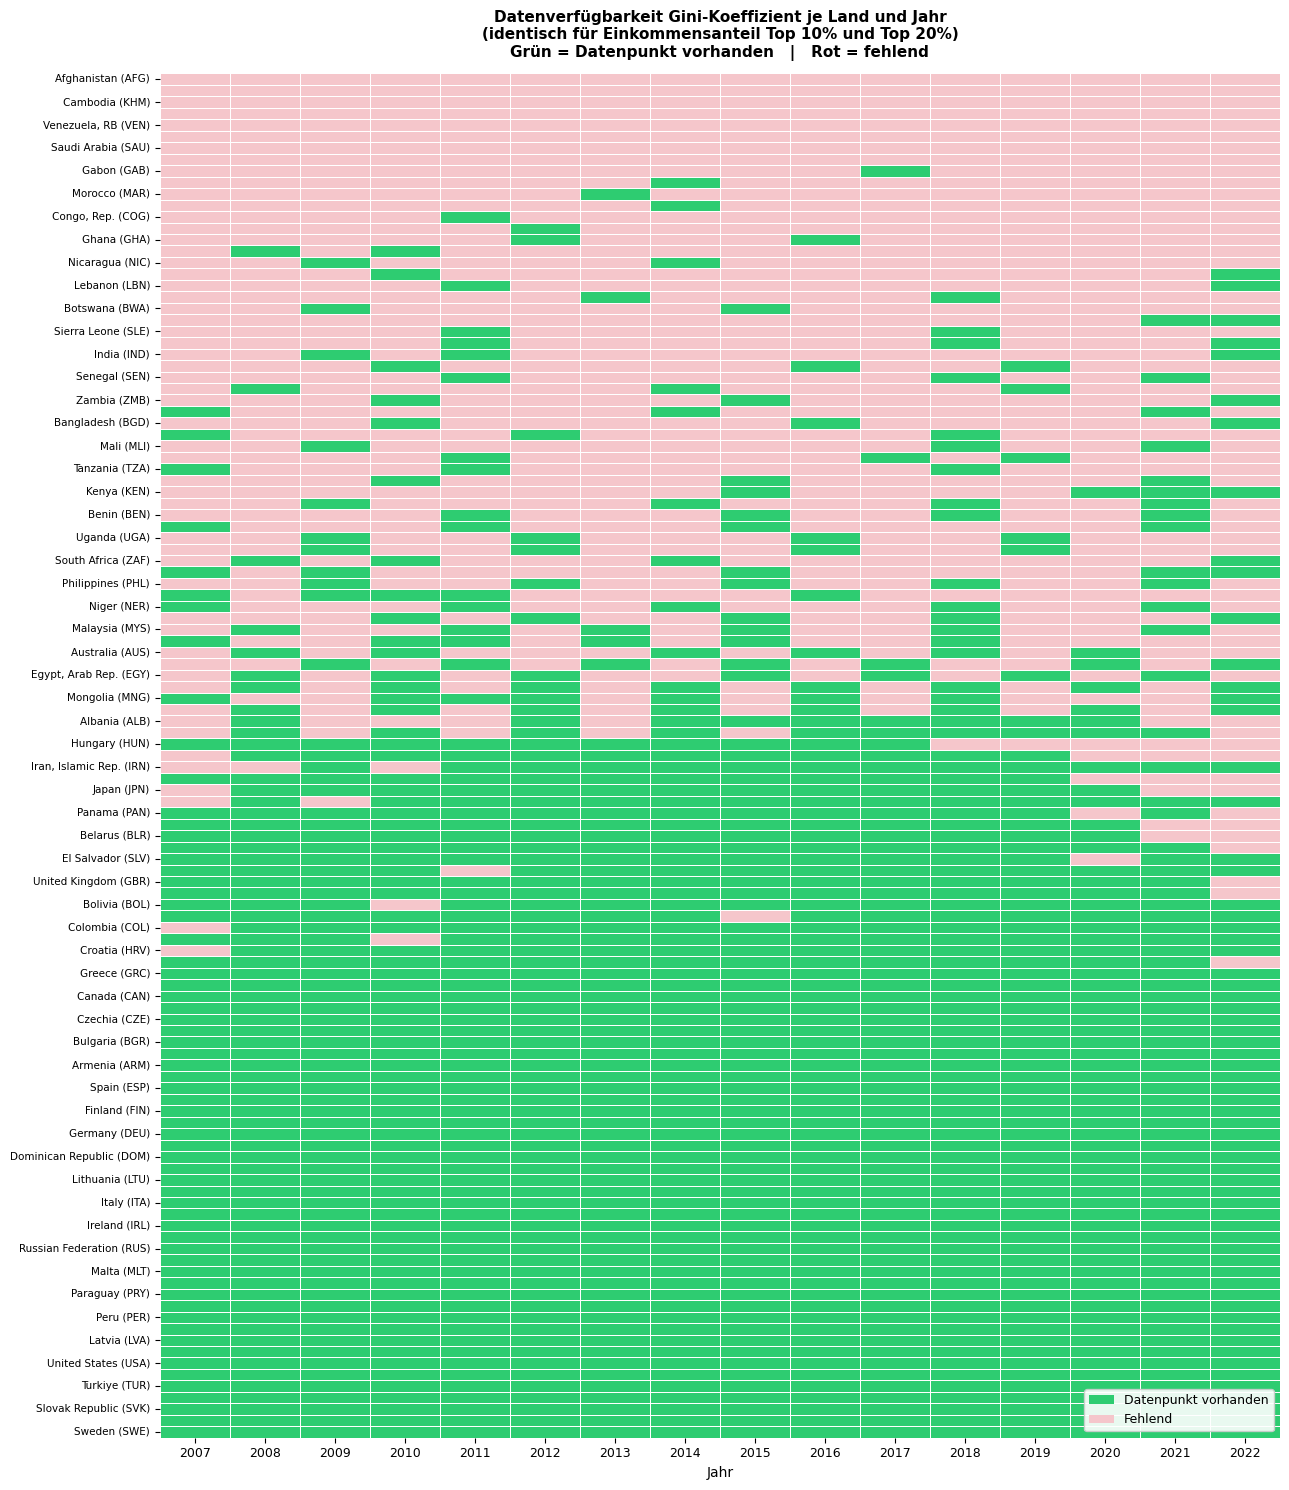

In [141]:
# --- Länder ohne Daten und Länder mit 1-4 Datenpunkten ----------------
no_data  = years_per_country[years_per_country['n_years'] == 0].sort_values('Country_Name')
few_data = (
    years_per_country[
        (years_per_country['n_years'] >= 1) & (years_per_country['n_years'] <= 4)
    ]
    .sort_values('n_years')
)

print(f'Laender OHNE jegliche Daten ({len(no_data)})')
print('Strukturursache: Keine verfügbaren Haushaltsbefragungen oder unveröffentlicht')
for r in no_data.itertuples():
    print(f'  {r.ISO3}  {r.Country_Name}')
print()

print(f'Laender mit nur 1-4 Messpunkten ({len(few_data)})')
print('Strukturursache: Nationale Erhebungen nur alle 5-10 Jahre (v.a. Sub-Sahara-Afrika)')
for _, row in few_data.iterrows():
    years_avail = sorted(
        df_gini_study[
            (df_gini_study['ISO3'] == row['ISO3']) &
            df_gini_study['Value'].notna()
        ]['Year'].tolist()
    )
    print(f'  {row.ISO3}  {row.Country_Name:<35}  {row.n_years} Messjahr(e): {years_avail}')

# --- Heatmap: Datenverfügbarkeit je Land und Jahr ------------------------

# Pivot-Tabelle: 1 = Datenpunkt, 0 = fehlend
pivot = (
    df_gini_study
    .assign(has_data=lambda d: d['Value'].notna().astype(int))
    .pivot_table(
        index='ISO3', columns='Year', values='has_data',
        aggfunc='max', fill_value=0
    )
)

# Länder nach Gesamtzahl Datenpunkte sortieren (oben: wenigste Daten)
pivot = pivot.loc[years_per_country.sort_values('n_years')['ISO3'].values]

# Ländernamen als Index
pivot.index = [
    f'{iso3_to_name.get(c, c)} ({c})' for c in pivot.index
]

fig, ax = plt.subplots(figsize=(13, 15))

sns.heatmap(
    pivot,
    cmap=['#f5c6cb', '#2ecc71'],
    linewidths=0.4,
    linecolor='white',
    cbar=False,
    ax=ax
)

ax.set_title(
    'Datenverfügbarkeit Gini-Koeffizient je Land und Jahr\n'
    '(identisch für Einkommensanteil Top 10% und Top 20%)\n'
    'Grün = Datenpunkt vorhanden   |   Rot = fehlend',
    fontsize=11, fontweight='bold', pad=12
)
ax.set_xlabel('Jahr', fontsize=10)
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=7.5)
ax.tick_params(axis='x', labelsize=9)

from matplotlib.patches import Patch
ax.legend(
    handles=[
        Patch(facecolor='#2ecc71', label='Datenpunkt vorhanden'),
        Patch(facecolor='#f5c6cb', label='Fehlend')
    ],
    loc='lower right', fontsize=9, framealpha=0.9
)

plt.tight_layout()
plt.show()

**Fazit:** Die geringe Jahresabdeckung (~59%) ist kein zufälliger Datenfehler,
sondern ein **strukturelles Merkmal** der Ungleichheitsdaten:

| Gruppe | Länder | Strukturursache |
|--------|--------|------------------|
| **8 ohne Daten** | AFG, AZE, KHM, HKG, NZL, SAU, SGP, VEN | Keine Haushaltsbefragung im WB-Datensatz |
| **35 mit 1–4 Messpunkten** | Großteils Sub-Sahara-Afrika, Naher Osten | Nationale Erhebungen nur alle 5–10 Jahre |
| **13 mit 5–8 Messpunkten** | Diverse Entwicklungsländer | Erhebungen alle 3–5 Jahre |
| **59 mit 13–16 Messpunkten** | Europa, Latein­amerika, Ostasien | Jährliche/zweijährliche Erhebungen |

**Konsequenz für die Analyse:** Die drei Ungleichheitsindikatoren sind bei
jährlichen Panel-Daten nur bedingt einsetzbar — es sei denn, man interpoliert
oder schränkt die Länderauswahl auf gut versorgte Länder ein.

### 4.11 Staatsquote

**WDI-Code:** `GC.XPN.TOTL.GD.ZS`  
**Quelle:** World Bank World Development Indicators

In [142]:
FILE_4_11 = FURTHER_DB / 'Staatsquote.xls'
df_4_11  = read_wdi(FILE_4_11)
cov_4_11 = compute_coverage(df_4_11)
display_indicator_coverage(cov_4_11, 'Staatsquote', 'GC.XPN.TOTL.GD.ZS')
results.append({
    'Abschnitt':           '4.11',
    'Indikator':           'Staatsquote',
    'Code':                'GC.XPN.TOTL.GD.ZS',
    'Laenderabdeckung_pct': cov_4_11['country_pct'],
    'Jahresabdeckung_pct':  cov_4_11['year_pct'],
})

=== Staatsquote  [GC.XPN.TOTL.GD.ZS] ===
  Länderabdeckung: 105/119 Länder (88.2%)
  Jahresabdeckung: 77.2% (Ø Anteil Studienjahre je Land)



Year,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
Staatsquote,66.4%,68.9%,72.3%,73.9%,76.5%,78.2%,77.3%,81.5%,84.0%,82.4%,82.4%,81.5%,79.8%,79.8%,79.0%,70.6%


### 4.12 Zentralstaatsverschuldung (Global Debt Database)

**Quelle:** IMF Global Debt Database (Mbaye, Moreno-Badia & Chae, 2018)
**Spalte:** `cg_data` — Central Government Debt (% of GDP)
**Sonderfall:** IMF-Ländernamen statt ISO3; Mapping über manuelles Dictionary.

In [143]:
FILE_4_12 = FURTHER_DB / 'GlobalDebtDatabase.xlsx'
df_4_12   = read_global_debt(FILE_4_12, GDD_NAME_TO_ISO3)
cov_4_12  = compute_coverage(df_4_12)
display_indicator_coverage(cov_4_12, 'Zentralstaatsverschuldung (CG Debt)', 'IMF-GDD-CG')
results.append({
    'Abschnitt':            '4.12',
    'Indikator':            'Zentralstaatsverschuldung (CG Debt)',
    'Code':                 'IMF-GDD-CG',
    'Laenderabdeckung_pct': cov_4_12['country_pct'],
    'Jahresabdeckung_pct':  cov_4_12['year_pct'],
})

=== Zentralstaatsverschuldung (CG Debt)  [IMF-GDD-CG] ===
  Länderabdeckung: 108/119 Länder (90.8%)
  Jahresabdeckung: 90.1% (Ø Anteil Studienjahre je Land)



Year,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
Zentralstaatsverschuldung (CG Debt),90.8%,90.8%,89.9%,90.8%,90.8%,90.8%,90.8%,90.8%,90.8%,90.8%,90.8%,90.8%,89.9%,88.2%,88.2%,87.4%


### 4.13 SWIID — Standardized World Income Inequality Database

**Quelle:** Solt (2019/2020), Harvard Dataverse — SWIID v9.92  
**Datei:** `dataverse_files.zip` → `swiid9_92.zip` → `swiid9_92_summary.csv`  
**Sonderfall:** Verschachteltes ZIP-Archiv; Ländernamen statt ISO3.

Die SWIID enthält vier Indikatoren:

| Spalte | Beschreibung |
|--------|--------------|
| `gini_disp` | Gini-Koeffizient **verfügbares** Einkommen (nach Steuern & Transfers) |
| `gini_mkt` | Gini-Koeffizient **Markt**einkommen (vor Steuern & Transfers) |
| `abs_red` | Absolute Reduktion durch Umverteilung (`gini_mkt` − `gini_disp`) |
| `rel_red` | Relative Reduktion durch Umverteilung |

Die Werte sind **interpolierte Schätzungen** (Solt 2019, S. 3: *"more interpolated values"*);
jeder Wert kommt mit einem Standardfehler (`_se`-Spalte), der die Schätzunsicherheit ausdrückt.
Höhere Standardfehler zeigen grössere zeitliche Distanz zur nächsten echten Befragung an.

In [144]:
# SWIID-Daten laden
FILE_4_13 = FURTHER_DB / 'dataverse_files.zip'
df_swiid  = read_swiid(FILE_4_13, SWIID_NAME_TO_ISO3)

# Alle 4 Indikatoren analysieren
SWIID_INDICATORS = [
    ('gini_disp', 'Gini verfügbares Einkommen (post-tax/transfer)', 'SWIID-GINI-DISP'),
    ('gini_mkt',  'Gini Markteinkommen (pre-tax/transfer)',          'SWIID-GINI-MKT'),
    ('abs_red',   'Absolute Umverteilungsreduktion',                 'SWIID-ABS-RED'),
    ('rel_red',   'Relative Umverteilungsreduktion',                 'SWIID-REL-RED'),
]

cov_swiid = {}  # Coverage-Ergebnisse je Indikator speichern

for col, label, ind_code in SWIID_INDICATORS:
    # Long-Format: eine Zeile pro (ISO3, Jahr)
    df_long = (
        df_swiid[['ISO3', 'year', col]]
        .rename(columns={'year': 'Year', col: 'Value'})
    )
    cov = compute_coverage(df_long)
    cov_swiid[col] = cov
    display_indicator_coverage(cov, label, ind_code)
    results.append({
        'Abschnitt':            '4.13',
        'Indikator':            label,
        'Code':                 ind_code,
        'Laenderabdeckung_pct': cov['country_pct'],
        'Jahresabdeckung_pct':  cov['year_pct'],
    })

=== Gini verfügbares Einkommen (post-tax/transfer)  [SWIID-GINI-DISP] ===
  Länderabdeckung: 117/119 Länder (98.3%)
  Jahresabdeckung: 92.0% (Ø Anteil Studienjahre je Land)



Year,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
Gini verfügbares Einkommen (post-tax/transfer),97.5%,98.3%,97.5%,97.5%,97.5%,97.5%,96.6%,96.6%,95.0%,94.1%,93.3%,90.8%,86.6%,82.4%,79.8%,70.6%


=== Gini Markteinkommen (pre-tax/transfer)  [SWIID-GINI-MKT] ===
  Länderabdeckung: 117/119 Länder (98.3%)
  Jahresabdeckung: 92.0% (Ø Anteil Studienjahre je Land)



Year,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
Gini Markteinkommen (pre-tax/transfer),97.5%,98.3%,97.5%,97.5%,97.5%,97.5%,96.6%,96.6%,95.0%,94.1%,93.3%,90.8%,86.6%,82.4%,79.8%,70.6%


=== Absolute Umverteilungsreduktion  [SWIID-ABS-RED] ===
  Länderabdeckung: 66/119 Länder (55.5%)
  Jahresabdeckung: 54.5% (Ø Anteil Studienjahre je Land)



Year,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
Absolute Umverteilungsreduktion,55.5%,55.5%,55.5%,55.5%,55.5%,55.5%,55.5%,55.5%,54.6%,54.6%,54.6%,53.8%,53.8%,53.8%,52.9%,50.4%


=== Relative Umverteilungsreduktion  [SWIID-REL-RED] ===
  Länderabdeckung: 66/119 Länder (55.5%)
  Jahresabdeckung: 54.5% (Ø Anteil Studienjahre je Land)



Year,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
Relative Umverteilungsreduktion,55.5%,55.5%,55.5%,55.5%,55.5%,55.5%,55.5%,55.5%,54.6%,54.6%,54.6%,53.8%,53.8%,53.8%,52.9%,50.4%


#### Standardfehler-Verteilung bei gini_disp und gini_mkt

Da `gini_disp` und `gini_mkt` interpolierte Schätzungen enthalten, ist der
Standardfehler (`_se`) ein wichtiges Qualitätsmerkmal: niedrige SE-Werte
entsprechen Zeitpunkten nahe einer echten Befragung, hohe SE-Werte
entsprechen weit interpolierten Jahren.

gini_disp (verfügbares Einkommen): 1751 Beobachtungen | Median SE = 1.20 | 70.1% mit SE < 2.0
gini_mkt (Markteinkommen): 1751 Beobachtungen | Median SE = 1.85 | 55.0% mit SE < 2.0


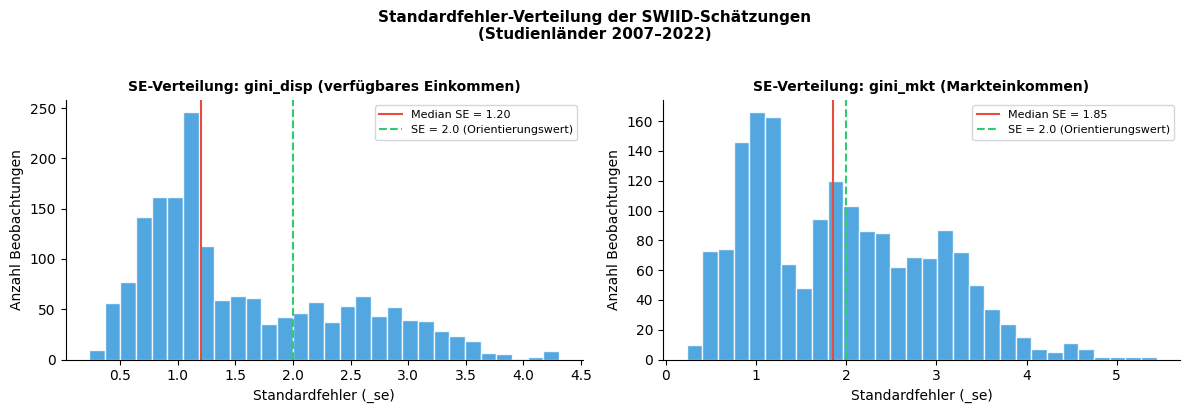

In [145]:
# SE-Analyse fuer gini_disp und gini_mkt
df_swiid_study = df_swiid[
    df_swiid['ISO3'].isin(INCLUDED_COUNTRIES) &
    df_swiid['year'].between(YEAR_START, YEAR_END)
].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (col_se, label) in zip(axes, [
    ('gini_disp_se', 'gini_disp (verfügbares Einkommen)'),
    ('gini_mkt_se',  'gini_mkt (Markteinkommen)'),
]):
    se_vals = df_swiid_study[col_se].dropna()

    ax.hist(se_vals, bins=30, color='#3498db', edgecolor='white', alpha=0.85)
    ax.axvline(se_vals.median(), color='#e74c3c', linewidth=1.5,
               label=f'Median SE = {se_vals.median():.2f}')
    ax.axvline(2.0, color='#2ecc71', linewidth=1.5, linestyle='--',
               label='SE = 2.0 (Orientierungswert)')
    ax.set_title(f'SE-Verteilung: {label}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Standardfehler (_se)')
    ax.set_ylabel('Anzahl Beobachtungen')
    ax.legend(fontsize=8)

    pct_below2 = (se_vals < 2.0).mean() * 100
    print(f'{label}: {len(se_vals)} Beobachtungen | '
          f'Median SE = {se_vals.median():.2f} | '
          f'{pct_below2:.1f}% mit SE < 2.0')

sns.despine()
plt.suptitle(
    f'Standardfehler-Verteilung der SWIID-Schätzungen\n'
    f'(Studienländer {YEAR_START}–{YEAR_END})',
    fontsize=11, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

## 5 -- Gesamtübersicht

Zusammenfassung der Länder- und Jahresabdeckung aller Indikatoren.
Die Schwellenwerte aus Notebook 01 sind eingezeichnet:
- **Länderabdeckung ≥ 80%**
- **Jahresabdeckung ≥ 75%**

In [146]:
summary_df = (
    pd.DataFrame(results)
    .sort_values('Laenderabdeckung_pct', ascending=False)
    .reset_index(drop=True)
)

# ── Styled Tabelle (wie Notebook 01) ──────────────────────────
print(f'=== Coverage-Übersicht: {len(summary_df)} Indikatoren ===')
print(f'    Basis: {N_COUNTRIES} Länder, {N_YEARS} Jahre ({YEAR_START}–{YEAR_END})')
print()

display(
    summary_df[['Abschnitt', 'Indikator', 'Code',
                'Laenderabdeckung_pct', 'Jahresabdeckung_pct']]
    .rename(columns={
        'Laenderabdeckung_pct': 'Länderabdeckung (%)',
        'Jahresabdeckung_pct':  'Jahresabdeckung (%)',
    })
    .style
    .format({'Länderabdeckung (%)': '{:.1f}%', 'Jahresabdeckung (%)': '{:.1f}%'})
    .background_gradient(
        cmap='RdYlGn',
        subset=['Länderabdeckung (%)', 'Jahresabdeckung (%)'],
        vmin=0, vmax=100
    )
    .applymap(
        lambda v: 'font-weight: bold' if isinstance(v, float) and v >= 75 else '',
        subset=['Jahresabdeckung (%)']
    )
    .set_caption(
        f'Datenabdeckung je Indikator — '
        f'Schwellenwerte: Länder ≥ 80%, Jahre ≥ 75% (wie Notebook 01)'
    )
)

=== Coverage-Übersicht: 16 Indikatoren ===
    Basis: 119 Länder, 16 Jahre (2007–2022)



,Abschnitt,Indikator,Code,Länderabdeckung (%),Jahresabdeckung (%)
0,4.1,Inflation (CPI),FP.CPI.TOTL.ZG,100.0%,97.7%
1,4.2,BIP-Deflator,NY.GDP.DEFL.KD.ZG,100.0%,99.8%
2,4.7,Kreditvergabe Privatsektor,FS.AST.PRVT.GD.ZS,100.0%,90.4%
3,4.3,Terms of Trade,TT.PRI.MRCH.XD.WD,99.2%,98.9%
4,4.13,Gini verfügbares Einkommen (post-tax/transfer),SWIID-GINI-DISP,98.3%,92.0%
5,4.13,Gini Markteinkommen (pre-tax/transfer),SWIID-GINI-MKT,98.3%,92.0%
6,4.5,Leistungsbilanzsaldo,BN.CAB.XOKA.GD.ZS,97.5%,95.8%
7,4.8,Gini-Koeffizient,SI.POV.GINI,93.3%,59.3%
8,4.9,Einkommensanteil Top 20%,SI.DST.05TH.20,93.3%,59.3%
9,4.10,Einkommensanteil Top 10%,SI.DST.10TH.10,93.3%,59.3%


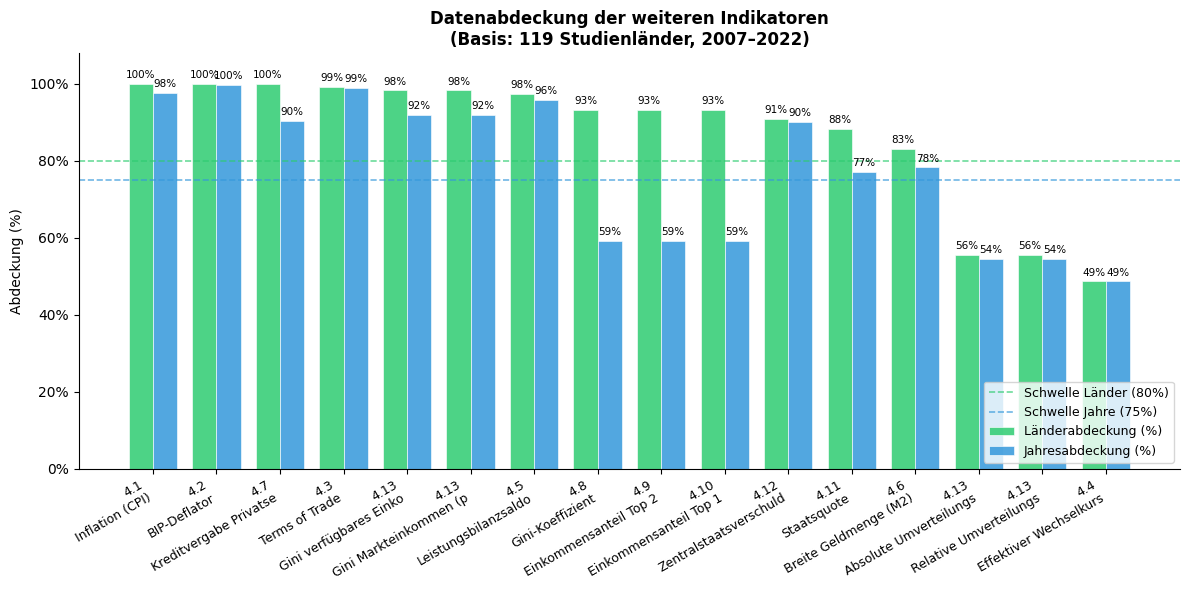

In [147]:
# ── Visualisierung: Grouped Bar Chart ────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

x     = np.arange(len(summary_df))
width = 0.38

bars_l = ax.bar(x - width/2, summary_df['Laenderabdeckung_pct'],
                width, label='Länderabdeckung (%)', color='#2ecc71', alpha=0.85,
                edgecolor='white', linewidth=0.5)
bars_j = ax.bar(x + width/2, summary_df['Jahresabdeckung_pct'],
                width, label='Jahresabdeckung (%)',  color='#3498db', alpha=0.85,
                edgecolor='white', linewidth=0.5)

# Schwellenwerte
ax.axhline(80, color='#2ecc71', linestyle='--', linewidth=1.2, alpha=0.7, label='Schwelle Länder (80%)')
ax.axhline(75, color='#3498db', linestyle='--', linewidth=1.2, alpha=0.7, label='Schwelle Jahre (75%)')

# Beschriftung
ax.set_xticks(x)
ax.set_xticklabels(
    [f'{row.Abschnitt}\n{row.Indikator[:22]}' for row in summary_df.itertuples()],
    rotation=30, ha='right', fontsize=9
)
ax.set_ylabel('Abdeckung (%)')
ax.set_ylim(0, 108)
ax.set_title(
    f'Datenabdeckung der weiteren Indikatoren\n'
    f'(Basis: {N_COUNTRIES} Studienländer, {YEAR_START}–{YEAR_END})',
    fontsize=12, fontweight='bold'
)
ax.legend(loc='lower right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

# Werte über den Balken
for bar in list(bars_l) + list(bars_j):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 1,
            f'{h:.0f}%', ha='center', va='bottom', fontsize=7.5)

sns.despine()
plt.tight_layout()
plt.show()

## 6 -- Export

In [150]:
OUTPUT_COVERAGE_FURTHER = OUTPUT_DIR / 'further_indicator_coverage.xlsx'

# Nur Indikatoren oberhalb beider Schwellenwerte exportieren
above_threshold = summary_df[
    (summary_df['Laenderabdeckung_pct'] >= 80) &
    (summary_df['Jahresabdeckung_pct']  >= 75)
].reset_index(drop=True)

# Datenbankname je Indikator
CODE_TO_DB = {
    'FP.CPI.TOTL.ZG':    'World Development Indicators (World Bank)',
    'NY.GDP.DEFL.KD.ZG': 'World Development Indicators (World Bank)',
    'TT.PRI.MRCH.XD.WD': 'World Development Indicators (World Bank)',
    'BN.CAB.XOKA.GD.ZS': 'World Development Indicators (World Bank)',
    'FM.LBL.BMNY.GD.ZS': 'World Development Indicators (World Bank)',
    'FS.AST.PRVT.GD.ZS': 'World Development Indicators (World Bank)',
    'GC.XPN.TOTL.GD.ZS': 'World Development Indicators (World Bank)',
    'IMF-GDD-CG':         'IMF Global Debt Database (Mbaye et al. 2018)',
    'SWIID-GINI-DISP':    'SWIID v9.92 (Solt 2019)',
    'SWIID-GINI-MKT':     'SWIID v9.92 (Solt 2019)',
}

# Kurzbeschreibung je Indikator
CODE_TO_DESC = {
    'FP.CPI.TOTL.ZG':    'Jaehrliche Veraenderung des Verbraucherpreisindex (% p.a.)',
    'NY.GDP.DEFL.KD.ZG': 'Verhaeltnis Nominal- zu Real-BIP: Preisniveauaenderung aller produzierten Gueter (% p.a.)',
    'TT.PRI.MRCH.XD.WD': 'Verhaeltnis Exportpreise zu Importpreisen (Index, 2015=100)',
    'BN.CAB.XOKA.GD.ZS': 'Nettoglaeubiger- (+) oder Nettoschuldnerposition (-) gegenueber dem Ausland aus Gueter-, DL- und Einkommensverkehr (% des BIP)',
    'FM.LBL.BMNY.GD.ZS': 'Bargeld, Sicht- und kurzfristige Spareinlagen (% des BIP)',
    'FS.AST.PRVT.GD.ZS': 'Bankkredite an Unternehmen und Haushalte (% des BIP)',
    'GC.XPN.TOTL.GD.ZS': 'Gesamte Staatsausgaben inkl. Transfers (% des BIP)',
    'IMF-GDD-CG':         'Schuldenstand des Zentralstaats (% des BIP)',
    'SWIID-GINI-DISP':    'Einkommensungleichheit nach Steuern und Transfers (0-100)',
    'SWIID-GINI-MKT':     'Einkommensungleichheit vor Steuern und Transfers (0-100)',
}

above_threshold.insert(3, 'Datenbank',    above_threshold['Code'].map(CODE_TO_DB))
above_threshold.insert(4, 'Beschreibung', above_threshold['Code'].map(CODE_TO_DESC))

with pd.ExcelWriter(OUTPUT_COVERAGE_FURTHER, engine='openpyxl') as writer:

    # Tab 1: Alle Indikatoren ueber beiden Schwellenwerten
    above_threshold.to_excel(writer, sheet_name='Selected_Indicators', index=False)

    # Tab 2: SWIID-Indikatoren separat (nur die, die ueber den Schwellenwerten liegen)
    swiid_above = above_threshold[above_threshold['Code'].str.startswith('SWIID')]
    swiid_above.to_excel(writer, sheet_name='SWIID_Selected', index=False)

print(f'Gespeichert: {OUTPUT_COVERAGE_FURTHER}')
print(f'  Tab "Selected_Indicators": {len(above_threshold)} Indikatoren '
      f'(>=80% Laender & >=75% Jahre)')
print(f'  Tab "SWIID_Selected":      {len(swiid_above)} SWIID-Indikatoren')
print()
print('Enthaltene Indikatoren:')
for _, row in above_threshold.iterrows():
    print(f'  [{row["Abschnitt"]}] {row["Indikator"]}')
    print(f'       Beschreibung: {row["Beschreibung"]}')
    print(f'       Datenbank:    {row["Datenbank"]}')
    print(f'       Coverage:     {row["Laenderabdeckung_pct"]:.1f}% Laender | {row["Jahresabdeckung_pct"]:.1f}% Jahre')

Gespeichert: Created Files for Analysis\further_indicator_coverage.xlsx
  Tab "Selected_Indicators": 10 Indikatoren (>=80% Laender & >=75% Jahre)
  Tab "SWIID_Selected":      2 SWIID-Indikatoren

Enthaltene Indikatoren:
  [4.1] Inflation (CPI)
       Beschreibung: Jaehrliche Veraenderung des Verbraucherpreisindex (% p.a.)
       Datenbank:    World Development Indicators (World Bank)
       Coverage:     100.0% Laender | 97.7% Jahre
  [4.2] BIP-Deflator
       Beschreibung: Verhaeltnis Nominal- zu Real-BIP: Preisniveauaenderung aller produzierten Gueter (% p.a.)
       Datenbank:    World Development Indicators (World Bank)
       Coverage:     100.0% Laender | 99.8% Jahre
  [4.7] Kreditvergabe Privatsektor
       Beschreibung: Bankkredite an Unternehmen und Haushalte (% des BIP)
       Datenbank:    World Development Indicators (World Bank)
       Coverage:     100.0% Laender | 90.4% Jahre
  [4.3] Terms of Trade
       Beschreibung: Verhaeltnis Exportpreise zu Importpreisen (Index, 20